<a href="https://colab.research.google.com/github/ilya-agafonov/dsp-seminars/blob/agafonov_lab6/seminars/6_Agafonov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


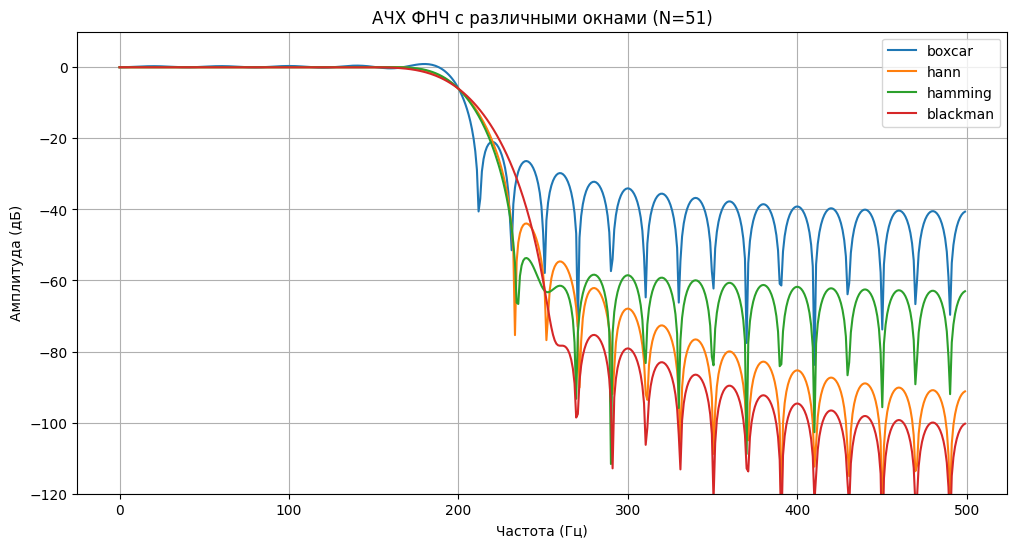

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 1000
numtaps = 51
cutoff = 200

windows = ['boxcar', 'hann', 'hamming', 'blackman']

plt.figure(figsize=(12, 6))

for win in windows:
    b = signal.firwin(numtaps, cutoff, window=win, fs=fs)
    w, h = signal.freqz(b, fs=fs)
    mag_dB = 20 * np.log10(np.abs(h) + 1e-12)
    plt.plot(w, mag_dB, label=win)

plt.title('АЧХ ФНЧ с различными окнами (N=51)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.legend()
plt.ylim(-120, 10)
plt.show()

**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

Ваши ответы здесь

### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


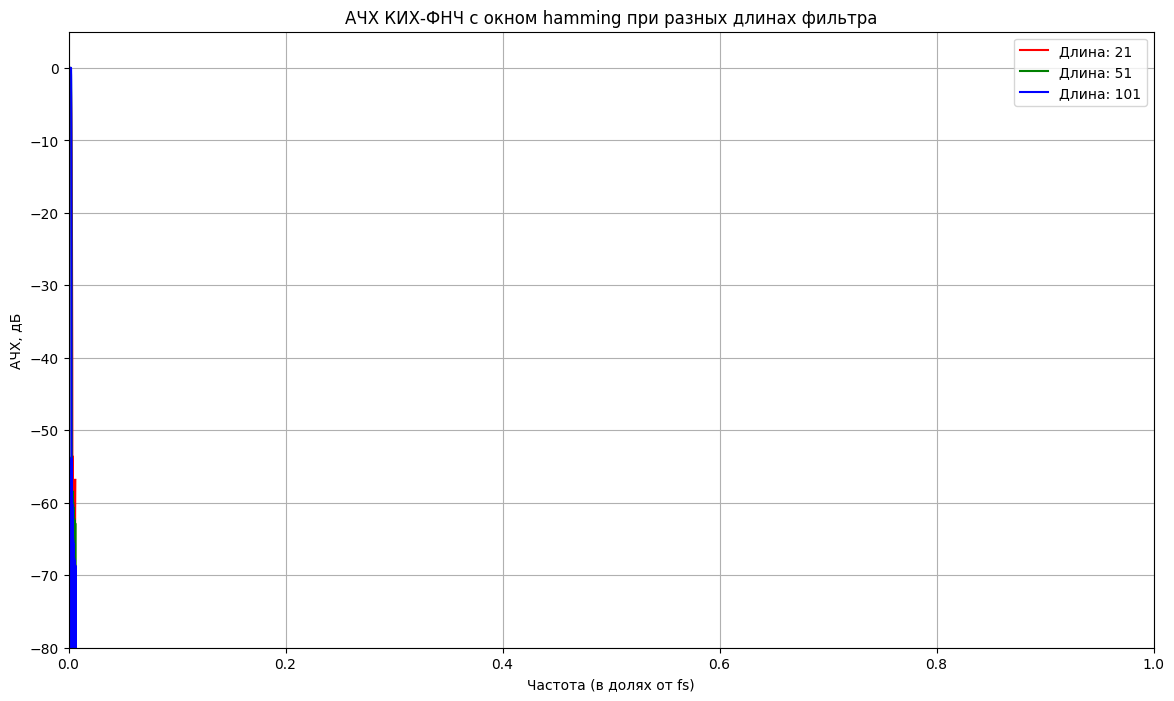

In [7]:
lengths = [21, 51, 101]

plt.figure(figsize=(12, 6))

for n in lengths:
    b = signal.firwin(n, cutoff, window='hamming', fs=fs)
    w, h = signal.freqz(b, fs=fs)
    mag_dB = 20 * np.log10(np.abs(h) + 1e-12)
    plt.plot(w, mag_dB, label=f'N = {n}')

plt.title('АЧХ ФНЧ (окно Хемминга) при разной длине')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.legend()
plt.ylim(-100, 10)
plt.show()

**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

Ваш ответ здесь


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


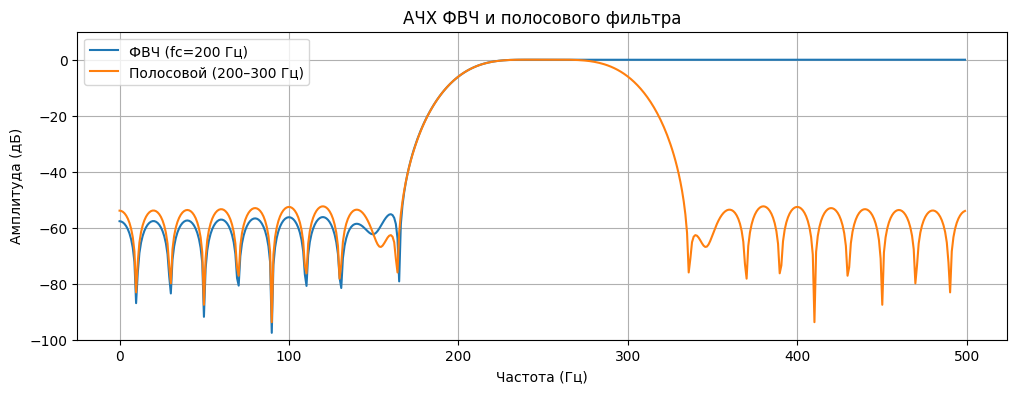

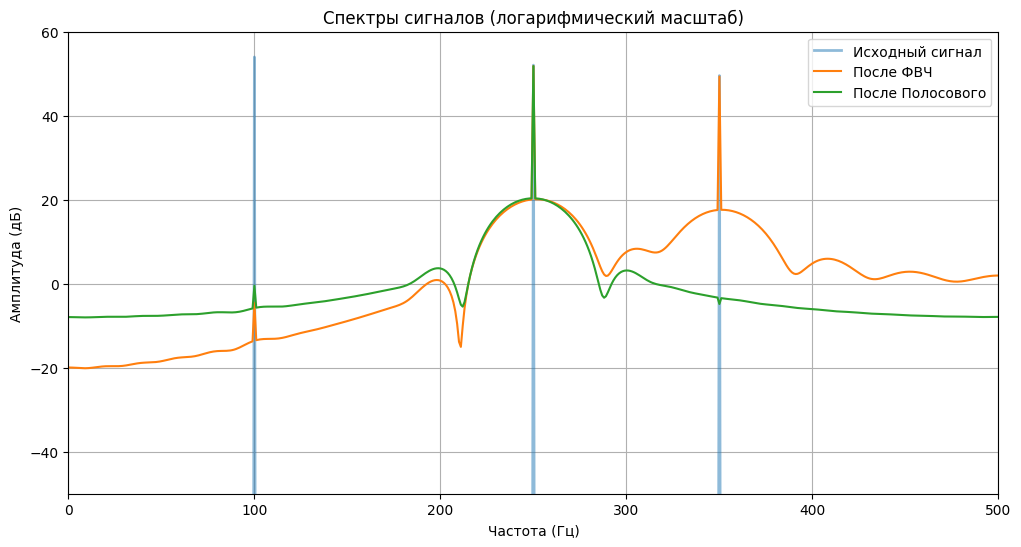

In [4]:
# --- 1. Проектирование фильтров ---
# ФВЧ (pass_zero=False делает фильтр пропускающим высокие частоты)
b_high = signal.firwin(51, 200, pass_zero=False, window='hamming', fs=fs)
# Полосовой фильтр (передаем массив частот и pass_zero=False)
b_band = signal.firwin(51, [200, 300], pass_zero=False, window='hamming', fs=fs)

w_h, h_high = signal.freqz(b_high, fs=fs)
w_b, h_band = signal.freqz(b_band, fs=fs)

plt.figure(figsize=(12, 4))
plt.plot(w_h, 20 * np.log10(np.abs(h_high) + 1e-12), label='ФВЧ (fc=200 Гц)')
plt.plot(w_b, 20 * np.log10(np.abs(h_band) + 1e-12), label='Полосовой (200–300 Гц)')
plt.title('АЧХ ФВЧ и полосового фильтра')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.legend()
plt.ylim(-100, 10)
plt.show()

# --- 2. Генерация и фильтрация сигнала ---
t = np.linspace(0, 1, fs, endpoint=False)
x = 1 * np.sin(2 * np.pi * 100 * t) + 0.8 * np.sin(2 * np.pi * 250 * t) + 0.6 * np.sin(2 * np.pi * 350 * t)

y_high = signal.lfilter(b_high, [1], x)
y_band = signal.lfilter(b_band, [1], x)

# --- 3. Спектры (БПФ) ---
freqs = np.fft.rfftfreq(len(x), 1/fs)
X_mag = 20 * np.log10(np.abs(np.fft.rfft(x)) + 1e-12)
Y_high_mag = 20 * np.log10(np.abs(np.fft.rfft(y_high)) + 1e-12)
Y_band_mag = 20 * np.log10(np.abs(np.fft.rfft(y_band)) + 1e-12)

plt.figure(figsize=(12, 6))
plt.plot(freqs, X_mag, label='Исходный сигнал', alpha=0.5, linewidth=2)
plt.plot(freqs, Y_high_mag, label='После ФВЧ')
plt.plot(freqs, Y_band_mag, label='После Полосового')
plt.title('Спектры сигналов (логарифмический масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.legend()
plt.xlim(0, 500)
plt.ylim(-50, 60)
plt.show()

Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

In [ ]:
# Ваш код здесь

**Вопрос:** Объясните полученные результаты.

Ваш ответ здесь

## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

In [ ]:
# Ваш код здесь


**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?

Ваши ответы здесь

### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


In [ ]:
# ваш код здесь

**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

Ваш ответ здесь

### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


In [ ]:
# Ваш код здесь

**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

Ваш ответ здесь

### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


In [ ]:
# Ваш код здесь

**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


Ваши ответы здесь

## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


In [ ]:
# Ваш код здесь

**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


Ваш ответ здесь

### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


In [ ]:
# Ваш код здесь

**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

Ваши ответы здесь

### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


In [ ]:
# Ваш код здесь

**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

Ваш ответ здесь

### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


In [ ]:
# Ваш код здесь

**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

Ваш ответ здесь

## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


In [ ]:
# Ваш код здесь

**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


Ваши ответы здесь

### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


In [ ]:
# Ваш код здесь

**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?

Ваши ответы здесь